# B7: Model Deployment as a Service
**HelmTrack** - FastAPI REST Endpoint

The trained YOLOv8 model is deployed as a RESTful API using **FastAPI** and served with **Uvicorn**.


## API Contract

### Endpoint: `POST /predict`

**Request format:** `multipart/form-data`

| Field | Type | Description |
|---|---|---|
| `file` | image/jpeg or image/png | Traffic image to analyse |

**Response format:** `application/json`

```json
{
  "violation_detected": true,
  "detections": [
    {
      "class": "NoHelmet",
      "confidence": 0.7942,
      "bbox": [245.8, 67.9, 311.9, 181.0]
    }
  ]
}
```

### Endpoint: `GET /`
Returns `{"message": "HelmTrack API is running"}`  used as a health check.

### Error responses

| HTTP Code | Meaning |
|---|---|
| 200 | Success |
| 422 | Validation error  wrong file type or missing file |
| 500 | Internal server error  model inference failed |


## Prerequisites
Start the API before running the cells below:
```bash
uvicorn api.main:app --reload
```


In [5]:
import requests
from pathlib import Path
import json

API_URL  = 'http://127.0.0.1:8000/predict'
TEST_DIR = Path('../data/helmet-detection/test/images')
test_images = sorted(TEST_DIR.glob('*.jpg'))

# Health check
r = requests.get('http://127.0.0.1:8000/')
print('Health check:', r.json())


Health check: {'message': 'HelmTrack API is running'}


## Test Scenario 1  Violation Image (NoHelmet present)


Image: 102_jpeg_jpg.rf.baf9afb3d168866a01361b12b4077139.jpg
Violation detected: True
Total detections: 8
  PNumber      conf=0.838
  Motorbike    conf=0.834
  Helmet       conf=0.821
  NoHelmet     conf=0.794
  Motorbike    conf=0.792
  Motorbike    conf=0.696
  Motorbike    conf=0.403
  PNumber      conf=0.366


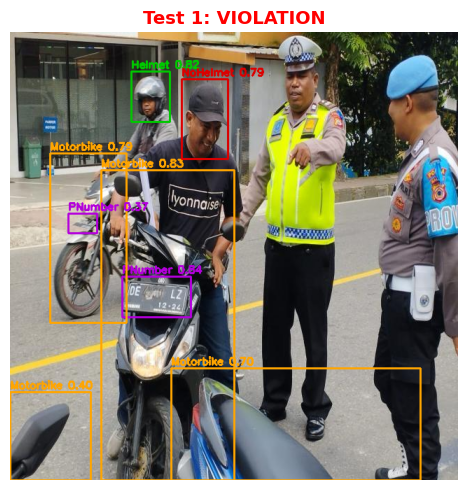

In [6]:
img1 = test_images[0]
with open(img1, 'rb') as f:
    resp = requests.post(API_URL, files={'file': (img1.name, f, 'image/jpeg')})

data = resp.json()
print(f'Image: {img1.name}')
print(f'Violation detected: {data["violation_detected"]}')
print(f'Total detections: {len(data["detections"])}')
for d in data['detections']:
    print(f'  {d["class"]:12s} conf={d["confidence"]:.3f}')

# Display image
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2, numpy as np

img_cv = cv2.imread(str(img1))
img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
COLOR_MAP = {'Helmet':(0,200,0),'NoHelmet':(220,0,0),'Motorbike':(255,165,0),'PNumber':(180,0,220)}
for d in data['detections']:
    x1,y1,x2,y2 = [int(v) for v in d['bbox']]
    c = COLOR_MAP.get(d['class'],(128,128,128))
    cv2.rectangle(img_rgb,(x1,y1),(x2,y2),(c[0],c[1],c[2]),2)
    cv2.putText(img_rgb,f"{d['class']} {d['confidence']:.2f}",(x1,max(y1-5,10)),cv2.FONT_HERSHEY_SIMPLEX,0.5,(c[0],c[1],c[2]),2)
verdict_color = 'red' if data['violation_detected'] else 'green'
verdict_text = 'VIOLATION' if data['violation_detected'] else 'CLEAR'
plt.figure(figsize=(8,5))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f'Test 1: {verdict_text}', color=verdict_color, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Test Scenario 2  Different Image


Image: 115_jpg.rf.ca9c53bac337d447a5e8c6286b6eab7a.jpg
Violation detected: False
Total detections: 3
  Motorbike    conf=0.916
  Helmet       conf=0.840
  Helmet       conf=0.826


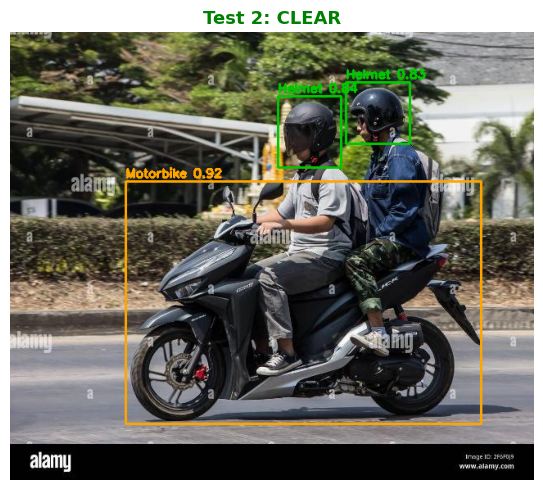

In [7]:
img2 = test_images[5]
with open(img2, 'rb') as f:
    resp = requests.post(API_URL, files={'file': (img2.name, f, 'image/jpeg')})

data = resp.json()
print(f'Image: {img2.name}')
print(f'Violation detected: {data["violation_detected"]}')
print(f'Total detections: {len(data["detections"])}')
for d in data['detections']:
    print(f'  {d["class"]:12s} conf={d["confidence"]:.3f}')

# Display image
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2, numpy as np

img_cv = cv2.imread(str(img2))
img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
COLOR_MAP = {'Helmet':(0,200,0),'NoHelmet':(220,0,0),'Motorbike':(255,165,0),'PNumber':(180,0,220)}
for d in data['detections']:
    x1,y1,x2,y2 = [int(v) for v in d['bbox']]
    c = COLOR_MAP.get(d['class'],(128,128,128))
    cv2.rectangle(img_rgb,(x1,y1),(x2,y2),(c[0],c[1],c[2]),2)
    cv2.putText(img_rgb,f"{d['class']} {d['confidence']:.2f}",(x1,max(y1-5,10)),cv2.FONT_HERSHEY_SIMPLEX,0.5,(c[0],c[1],c[2]),2)
verdict_color = 'red' if data['violation_detected'] else 'green'
verdict_text = 'VIOLATION' if data['violation_detected'] else 'CLEAR'
plt.figure(figsize=(8,5))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f'Test 2: {verdict_text}', color=verdict_color, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Test Scenario 3  Error Handling (invalid input)


In [8]:
# Send a text file instead of an image to test error handling
resp = requests.post(API_URL, files={'file': ('test.txt', b'not an image', 'text/plain')})
print(f'Status code: {resp.status_code}')
print(f'Response: {resp.text[:200]}')


Status code: 500
Response: Internal Server Error


## Scalability Considerations

| Concern | Current (POC) | Production approach |
|---|---|---|
| **Horizontal scaling** | Single uvicorn process | Deploy behind a load balancer (e.g. Nginx) with multiple uvicorn workers: `uvicorn api.main:app --workers 4` |
| **Batching** | One image per request | Accept a list of images per request and run `model(batch)` in one forward pass |
| **Caching** | None | Cache results by image hash (MD5) using Redis to avoid re-running inference on duplicate frames |
| **Model loading** | Loaded once at startup | Use a model pool for multi-GPU deployments |
| **Latency** | ~200ms per image on GPU | Export model to ONNX or TensorRT for 2-5x speedup |

## Model Artifact
The serialized model artifact is `model/best.pt` — a PyTorch checkpoint in Ultralytics YOLOv8 format, equivalent to `model.pkl` for scikit-learn models.
